# 🍔 Food Delivery Data Visualization Portfolio

## 📊 Matplotlib and Seaborn

### 📖 Introduction

This visualization portfolio explores the performance of a food delivery business using Matplotlib and Seaborn. The dataset contains information about orders, revenue, marketing spend, discounts, delivery time, customer ratings, cities, cuisines, weather conditions, and order channels.

Different visualizations are used to identify trends, compare categories, examine distributions, and understand the relationships between important business variables.

## 🎯 Objectives

The main objectives of this visualization portfolio are:

- To analyze changes in orders and revenue over time.
- To compare business performance across different cities and cuisines.
- To examine the relationship between marketing spend and revenue.
- To understand the relationship between delivery time and customer ratings.
- To study the distributions of orders, revenue, and delivery time.
- To compare performance under different weather conditions.
- To analyze the usage and performance of different order channels.
- To identify meaningful relationships between numerical variables using a correlation heatmap.
- To summarize the most important insights obtained from the visualizations.

## 1. Importing Required Libraries

The required Python libraries are imported for data handling and visualization.

- **Pandas** is used to load and analyze the dataset.
- **Matplotlib** is used to create and customize charts.
- **Seaborn** is used to create attractive statistical visualizations.

In [31]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
# Set a consistent style for all visualizations

sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Visualization style configured successfully!")

Visualization style configured successfully!


## 2. Loading the Dataset

The Food Delivery Business Performance Dataset is loaded into a Pandas DataFrame. The first five rows are displayed to obtain an initial understanding of the available variables and records.

In [33]:
# Load the Food Delivery dataset

df = pd.read_csv("Food_Delivery_Visualization_Dataset.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


## 3. Understanding the Dataset

Before creating the visualizations, the structure and quality of the dataset are examined. This includes checking its dimensions, column names, data types, duplicate records, and missing values.

### 3.1 Dataset Dimensions

The number of rows and columns in the dataset is checked using the `shape` attribute.

In [34]:
# Check the dimensions of the dataset

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 360
Number of Columns: 16


### 3.2 Column Names

The column names are displayed to identify the variables available for the visualization analysis.

In [35]:
# Display all column names

print("Columns in the dataset:")

df.columns.tolist()

Columns in the dataset:


['Order_Batch_ID',
 'Date',
 'Month',
 'Day',
 'City',
 'Cuisine',
 'Order_Channel',
 'Weather',
 'Orders',
 'Average_Order_Value',
 'Revenue',
 'Marketing_Spend',
 'Discounts',
 'Avg_Delivery_Minutes',
 'Customer_Rating',
 'Repeat_Customer_Percent']

### 3.3 Dataset Information

The `info()` method provides a concise summary of the dataset, including the number of records, column names, non-null values, and data types.

In [36]:
# Display a summary of the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    str    
 1   Date                     360 non-null    str    
 2   Month                    360 non-null    str    
 3   Day                      360 non-null    str    
 4   City                     360 non-null    str    
 5   Cuisine                  360 non-null    str    
 6   Order_Channel            360 non-null    str    
 7   Weather                  360 non-null    str    
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          360 non-null

### 3.4 Missing Values

Missing values are checked to ensure that the dataset is complete and suitable for visualization. Missing data can affect the accuracy and interpretation of charts.

In [37]:
# Check the number of missing values in each column

df.isnull().sum()

Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64

### 3.5 Duplicate Records

Duplicate rows are checked because repeated records may produce misleading totals, averages, and visualizations.

In [38]:
# Check the number of duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


## 4. Data Preparation

### 4.1 Converting the Date Column

The `Date` column is converted from the object data type to the Pandas `datetime` format. This conversion is required for accurate time-based analysis and visualization.

In [39]:
# Convert the Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")

print("Date column converted successfully!")
print("Date column data type:", df["Date"].dtype)

Date column converted successfully!
Date column data type: datetime64[us]


### 4.2 Preparing the Data for Time-Based Analysis

A month number is extracted from the converted date column so that the monthly visualizations appear in correct chronological order. The dataset is also sorted by date.

In [40]:
# Extract the month number from the Date column

df["Month_Number"] = df["Date"].dt.month

# Sort the dataset in chronological order

df = df.sort_values(by="Date").reset_index(drop=True)

print("Data prepared for time-based analysis!")

df[["Date", "Month", "Month_Number"]].head()

Data prepared for time-based analysis!


,Date,Month,Month_Number
0,2025-01-02,January,1
1,2025-01-03,January,1
2,2025-01-03,January,1
3,2025-01-04,January,1
4,2025-01-05,January,1


### 4.3 Summary Statistics of Numerical Variables

Summary statistics are examined to understand the count, mean, standard deviation, minimum, maximum, and quartile values of the numerical variables before creating the visualizations.

In [42]:
# Display summary statistics of numerical columns

df.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
Orders,360.0,147.647222,33.387161,58.00,123.7500,147.00,169.0000,235.00
Average_Order_Value,360.0,409.151083,70.249186,243.76,353.8400,412.41,464.9450,575.94
Revenue,360.0,60591.114778,17387.926132,20618.53,48400.8325,58779.19,71740.1425,121381.98
Marketing_Spend,360.0,27161.430028,6970.558278,11336.64,21822.5000,25874.14,32387.1375,45000.00
Discounts,360.0,5753.397000,2647.410844,1219.31,3566.6150,5226.87,7610.3675,15000.00
Avg_Delivery_Minutes,360.0,32.577500,5.281562,20.60,28.6750,32.00,35.9500,50.10
Customer_Rating,360.0,4.452861,0.209699,3.81,4.3100,4.47,4.6100,4.94
Repeat_Customer_Percent,360.0,41.600000,5.336472,24.80,37.9000,41.90,45.2250,54.00
Month_Number,360.0,6.527778,3.403964,1.00,4.0000,6.00,9.0000,12.00


## 5. Time-Based Performance Analysis

### 5.1 Preparing Monthly Order and Revenue Data

The dataset is grouped by month to calculate the total number of orders and total revenue generated during each month. The month number is used to maintain the correct chronological order.

In [43]:
# Calculate total orders and revenue for each month

monthly_performance = (
    df.groupby(["Month_Number", "Month"], as_index=False)
      .agg(
          Total_Orders=("Orders", "sum"),
          Total_Revenue=("Revenue", "sum")
      )
      .sort_values("Month_Number")
)

monthly_performance

,Month_Number,Month,Total_Orders,Total_Revenue
0,1,January,3318,1307391.72
1,2,February,2853,1129272.69
2,3,March,5073,2143752.84
3,4,April,5343,2177469.56
4,5,May,3433,1395617.16
5,6,June,5816,2366928.56
6,7,July,4107,1737726.54
7,8,August,4951,1877308.87
8,9,September,3782,1515392.97
9,10,October,4534,1811552.37


### 5.2 Monthly Orders Trend – Line Plot

A line plot is used to examine how the total number of food delivery orders changes from January to December.

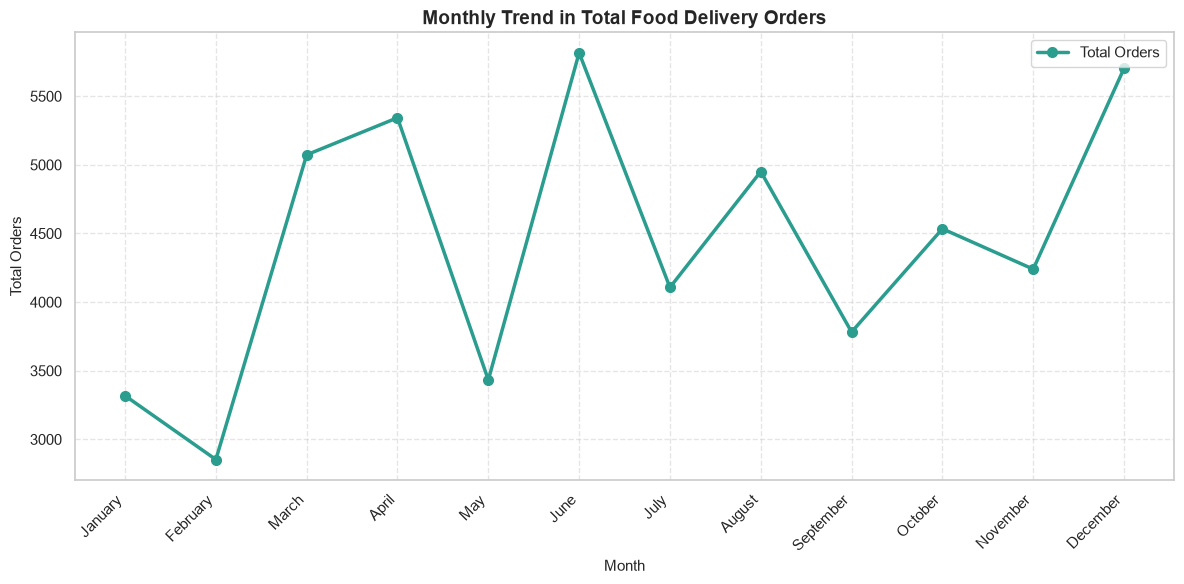

In [44]:
# Create a line plot of total monthly orders

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Total_Orders"],
    color="#2A9D8F",
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Total Orders"
)

plt.title("Monthly Trend in Total Food Delivery Orders", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### 💡 Interpretation

The total number of orders fluctuated considerably throughout the year rather than following a continuous upward or downward trend. June recorded the highest number of orders with **5,816 orders**, followed by December with **5,703 orders**, while February recorded the lowest with **2,853 orders**. This variation indicates that customer demand differed across months, with particularly strong order activity during June and December.

### 5.3 Monthly Revenue Trend – Line Plot

A line plot is used to visualize how the total revenue generated by the food delivery business changes across the twelve months.

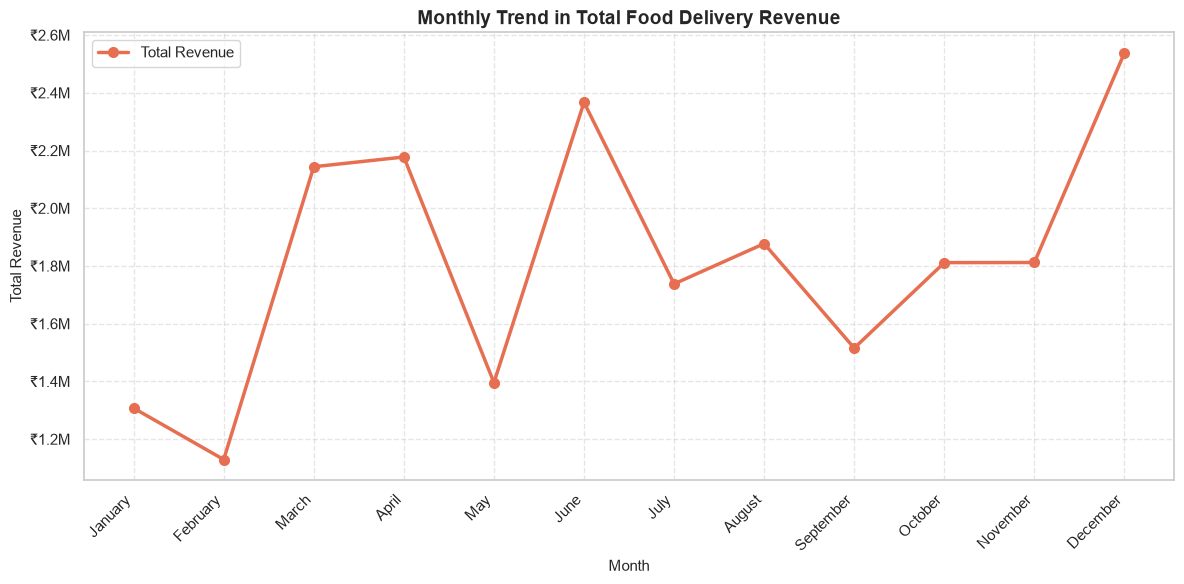

In [45]:
# Import a formatter for displaying revenue in millions

from matplotlib.ticker import FuncFormatter

# Create a line plot of total monthly revenue

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Total_Revenue"],
    color="#E76F51",
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Total Revenue"
)

# Format the Y-axis values in millions

revenue_formatter = FuncFormatter(
    lambda value, position: f"₹{value / 1_000_000:.1f}M"
)

plt.gca().yaxis.set_major_formatter(revenue_formatter)

plt.title("Monthly Trend in Total Food Delivery Revenue", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Monthly revenue also showed noticeable fluctuations during the year. December generated the highest total revenue of approximately **₹2.54 million**, followed by June with approximately **₹2.37 million**, whereas February recorded the lowest revenue of approximately **₹1.13 million**. The months with higher order volumes generally produced higher revenue, indicating that order activity is an important contributor to overall business income.

## 6. City-Wise Performance Analysis

### 6.1 Preparing the City-Wise Summary

The dataset is grouped by city to calculate total orders, total revenue, and average customer rating. The results are arranged in descending order of total revenue.

In [46]:
# Calculate city-wise performance measures

city_performance = (
    df.groupby("City", as_index=False)
      .agg(
          Total_Orders=("Orders", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Average_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

city_performance

,City,Total_Orders,Total_Revenue,Average_Rating
0,Bengaluru,9394,3851958.65,4.433962
2,Delhi,9288,3808183.88,4.406415
3,Hyderabad,7140,2824382.94,4.471667
6,Mumbai,6633,2730403.79,4.417317
7,Pune,5812,2406273.63,4.469286
4,Jaipur,4931,2129246.70,4.484048
1,Chandigarh,5002,2034416.22,4.492000
5,Kochi,4953,2027935.51,4.463902


### 6.2 Total Revenue by City – Bar Chart

A bar chart is used to compare the total revenue generated across different cities. The cities are arranged from the highest to the lowest revenue.

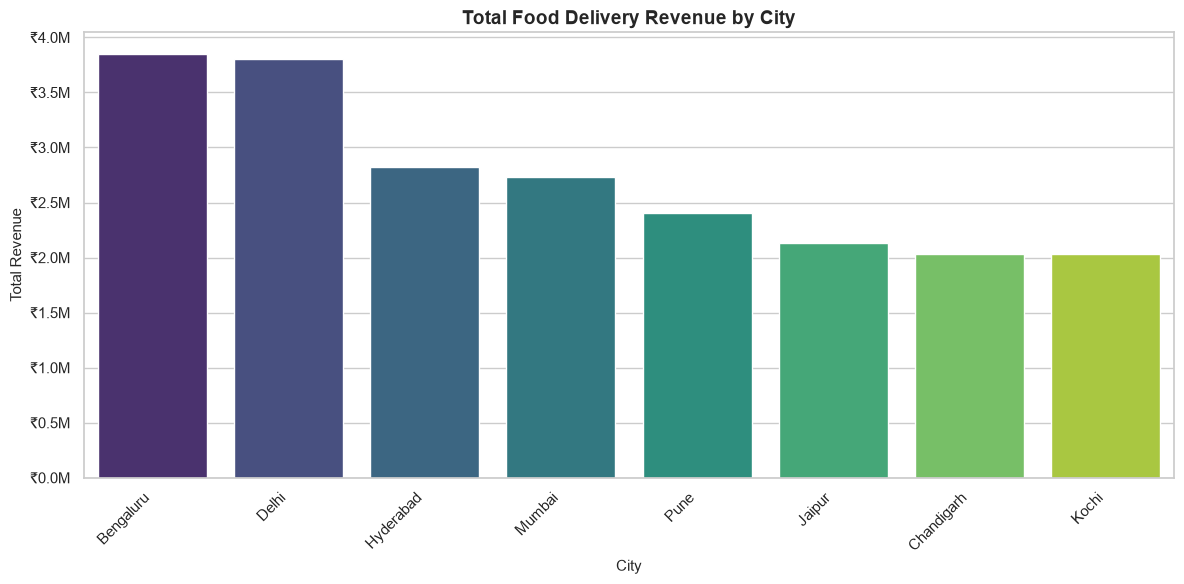

In [47]:
# Create a bar chart of total revenue by city

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=city_performance,
    x="City",
    y="Total_Revenue",
    hue="City",
    order=city_performance["City"],
    palette="viridis",
    legend=False
)

# Format revenue values in millions

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"₹{value / 1_000_000:.1f}M")
)

plt.title("Total Food Delivery Revenue by City", fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Bengaluru generated the highest total revenue of approximately **₹3.85 million**, closely followed by Delhi with approximately **₹3.81 million**. Kochi recorded the lowest total revenue at approximately **₹2.03 million**. The chart shows a clear difference in total business activity across cities, with Bengaluru and Delhi contributing the largest revenue amounts in the dataset.

## 7. Cuisine-Wise Performance Analysis

### 7.1 Preparing the Cuisine-Wise Summary

The dataset is grouped by cuisine to calculate total orders, total revenue, and average order value. The cuisines are arranged in descending order of total orders.

In [48]:
# Calculate cuisine-wise performance measures

cuisine_performance = (
    df.groupby("Cuisine", as_index=False)
      .agg(
          Total_Orders=("Orders", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Average_Order_Value=("Average_Order_Value", "mean")
      )
      .sort_values("Total_Orders", ascending=False)
)

cuisine_performance

,Cuisine,Total_Orders,Total_Revenue,Average_Order_Value
3,Healthy,10024,4988656.66,501.837206
1,Chinese,9167,3594364.34,386.094921
4,North Indian,9030,3915404.79,428.865410
2,Fast Food,8602,2715572.68,316.668621
5,South Indian,8189,2838647.33,344.853704
0,Biryani,8141,3760155.52,458.853750


### 7.2 Total Orders by Cuisine – Bar Chart

A bar chart is used to compare the total number of orders received for each cuisine. The cuisines are arranged from the highest to the lowest number of orders.

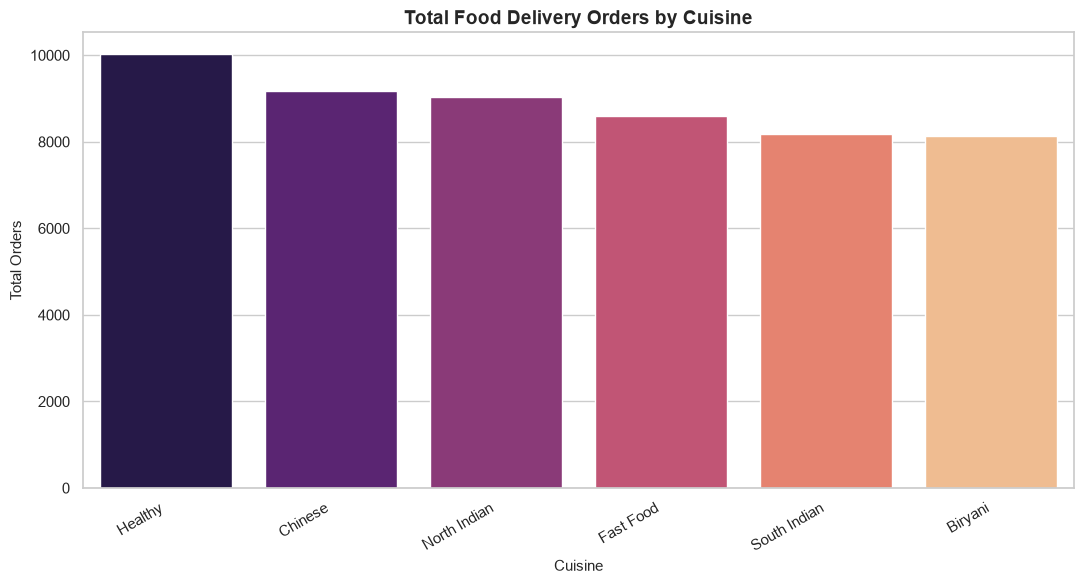

In [49]:
# Create a bar chart of total orders by cuisine

plt.figure(figsize=(11, 6))

sns.barplot(
    data=cuisine_performance,
    x="Cuisine",
    y="Total_Orders",
    hue="Cuisine",
    order=cuisine_performance["Cuisine"],
    palette="magma",
    legend=False
)

plt.title("Total Food Delivery Orders by Cuisine", fontweight="bold")
plt.xlabel("Cuisine")
plt.ylabel("Total Orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Healthy cuisine received the highest total number of orders with **10,024 orders**, followed by Chinese cuisine with **9,167 orders**. Biryani recorded the lowest total with **8,141 orders**, although the differences among the lower-ranked cuisines were relatively small. The result indicates that Healthy cuisine had the strongest overall demand in this dataset.

## 8. Relationship Analysis Using Scatter Plots

### 8.1 Marketing Spend vs Revenue

A scatter plot is used to examine whether higher marketing expenditure is associated with higher revenue. The points are colored according to the order channel, and a trend line is included to show the overall direction of the relationship.

Correlation between Marketing Spend and Revenue: 0.2


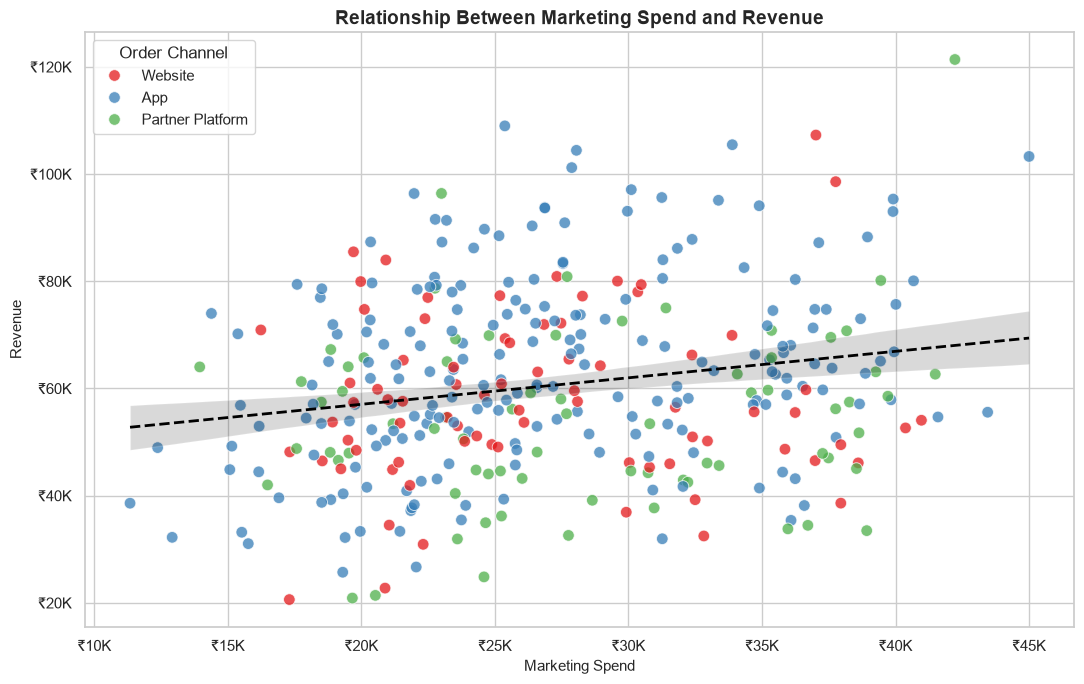

In [50]:
# Calculate the correlation between marketing spend and revenue

marketing_revenue_correlation = df["Marketing_Spend"].corr(df["Revenue"])

print(
    "Correlation between Marketing Spend and Revenue:",
    round(marketing_revenue_correlation, 2)
)

# Create the scatter plot

plt.figure(figsize=(11, 7))

ax = sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    hue="Order_Channel",
    palette="Set1",
    s=70,
    alpha=0.75
)

# Add an overall trend line

sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--", "linewidth": 2}
)

# Format both axes as currency

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"₹{value / 1_000:.0f}K")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"₹{value / 1_000:.0f}K")
)

plt.title("Relationship Between Marketing Spend and Revenue", fontweight="bold")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.legend(title="Order Channel")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

The correlation coefficient between marketing spend and revenue is approximately **0.20**, indicating a weak positive relationship. The slightly upward trend line suggests that revenue may increase as marketing spend increases, but the widely scattered points show that the relationship is not strong. Therefore, marketing spend alone does not explain revenue performance, and other factors such as order volume and average order value are also likely to be important.

### 8.2 Average Delivery Time vs Customer Rating

A scatter plot is used to investigate the relationship between average delivery time and customer rating. The points are colored according to weather conditions, and a trend line is added to show the overall direction of the relationship.

Correlation between Delivery Time and Customer Rating: -0.88


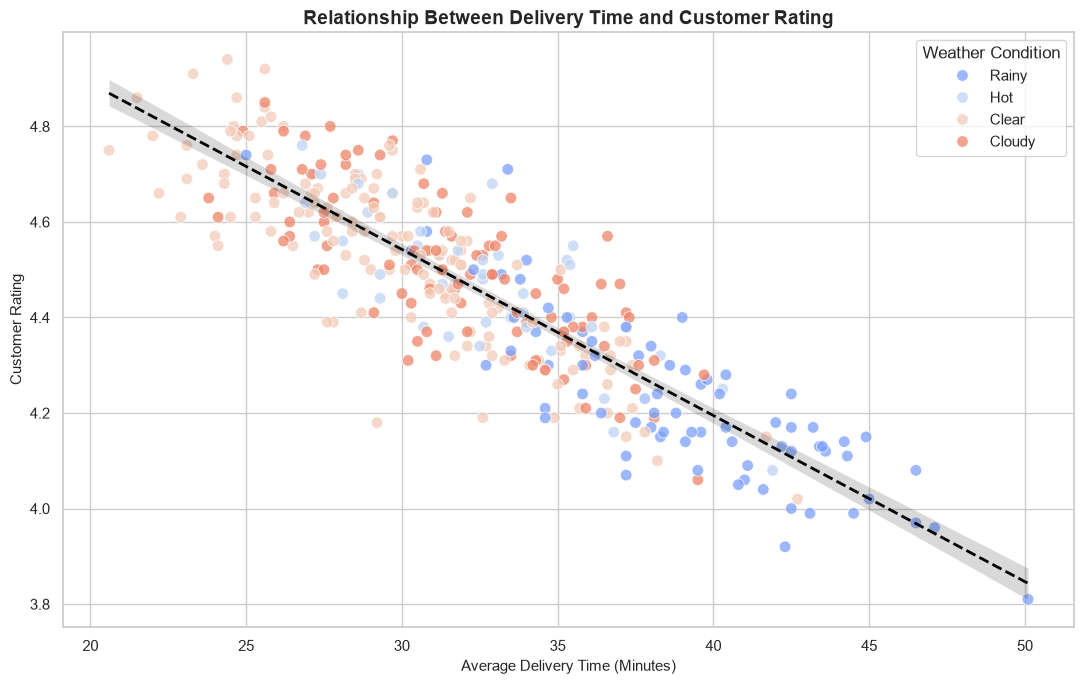

In [51]:
# Calculate the correlation between delivery time and customer rating

delivery_rating_correlation = df["Avg_Delivery_Minutes"].corr(
    df["Customer_Rating"]
)

print(
    "Correlation between Delivery Time and Customer Rating:",
    round(delivery_rating_correlation, 2)
)

# Create the scatter plot

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    hue="Weather",
    palette="coolwarm",
    s=70,
    alpha=0.75
)

# Add an overall trend line

sns.regplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--", "linewidth": 2}
)

plt.title(
    "Relationship Between Delivery Time and Customer Rating",
    fontweight="bold"
)
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.legend(title="Weather Condition")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

The correlation coefficient of approximately **−0.88** indicates a strong negative relationship between average delivery time and customer rating. As delivery time increases, customer ratings generally decrease. Rainy-weather observations also tend to appear more frequently among longer delivery times and lower ratings, suggesting that delivery efficiency is strongly associated with customer satisfaction.

## 9. Distribution Analysis 📊

### 9.1 Distribution of Revenue – Histogram

A histogram with a Kernel Density Estimate (KDE) curve is used to examine the distribution of revenue values. Vertical lines are added to compare the mean and median revenue.

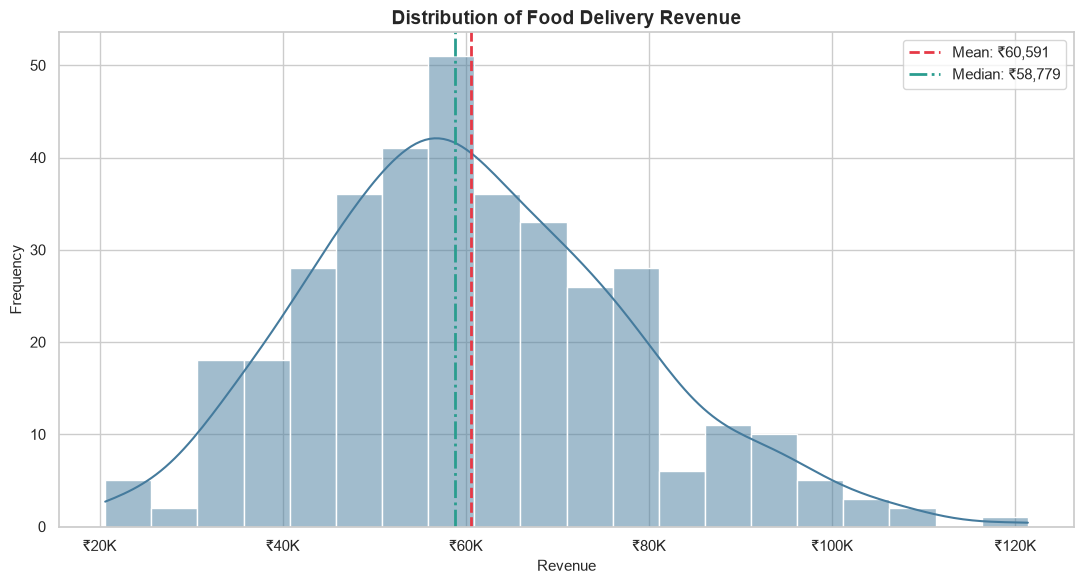

In [52]:
# Calculate the mean and median revenue

mean_revenue = df["Revenue"].mean()
median_revenue = df["Revenue"].median()

# Create the revenue histogram

plt.figure(figsize=(11, 6))

ax = sns.histplot(
    data=df,
    x="Revenue",
    bins=20,
    kde=True,
    color="#457B9D",
    edgecolor="white"
)

# Add mean and median reference lines

plt.axvline(
    mean_revenue,
    color="#E63946",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ₹{mean_revenue:,.0f}"
)

plt.axvline(
    median_revenue,
    color="#2A9D8F",
    linestyle="-.",
    linewidth=2,
    label=f"Median: ₹{median_revenue:,.0f}"
)

# Format the X-axis as currency

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"₹{value / 1_000:.0f}K")
)

plt.title("Distribution of Food Delivery Revenue", fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Revenue values range from approximately **₹20,619 to ₹121,382**, with most observations concentrated around the middle of this range. The mean revenue of approximately **₹60,591** is slightly higher than the median of approximately **₹58,779**, indicating a mildly right-skewed distribution. This suggests that a small number of high-revenue order batches increase the overall average.

## 10. Delivery Performance Across Weather Conditions 🌦️

### 10.1 Delivery Time by Weather – Box Plot

A box plot is used to compare the distribution of average delivery time across different weather conditions. It displays the median, spread, possible outliers, and overall variation within each weather category.

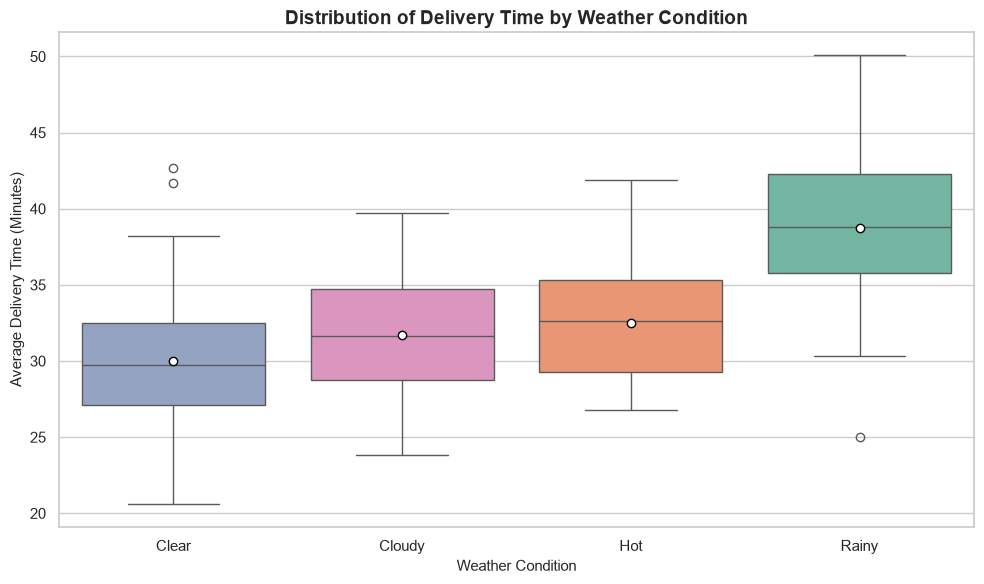

In [53]:
# Set a meaningful order for the weather categories

weather_order = ["Clear", "Cloudy", "Hot", "Rainy"]

# Create a box plot of delivery time by weather

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Weather",
    y="Avg_Delivery_Minutes",
    hue="Weather",
    order=weather_order,
    palette="Set2",
    legend=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black"
    }
)

plt.title("Distribution of Delivery Time by Weather Condition", fontweight="bold")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Minutes)")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Rainy weather recorded the longest delivery times, with an average of approximately **38.75 minutes** and a median of **38.80 minutes**. Clear weather had the shortest average delivery time at approximately **29.99 minutes**, while Cloudy and Hot conditions showed moderate delivery times. The result indicates that rainy conditions are associated with slower and more variable delivery performance.

## 11. Customer Ratings Across Order Channels

### 11.1 Customer Rating by Order Channel – Violin Plot

A violin plot is used to compare the distribution and density of customer ratings across the App, Website, and Partner Platform order channels. The internal lines represent the quartiles of each distribution.

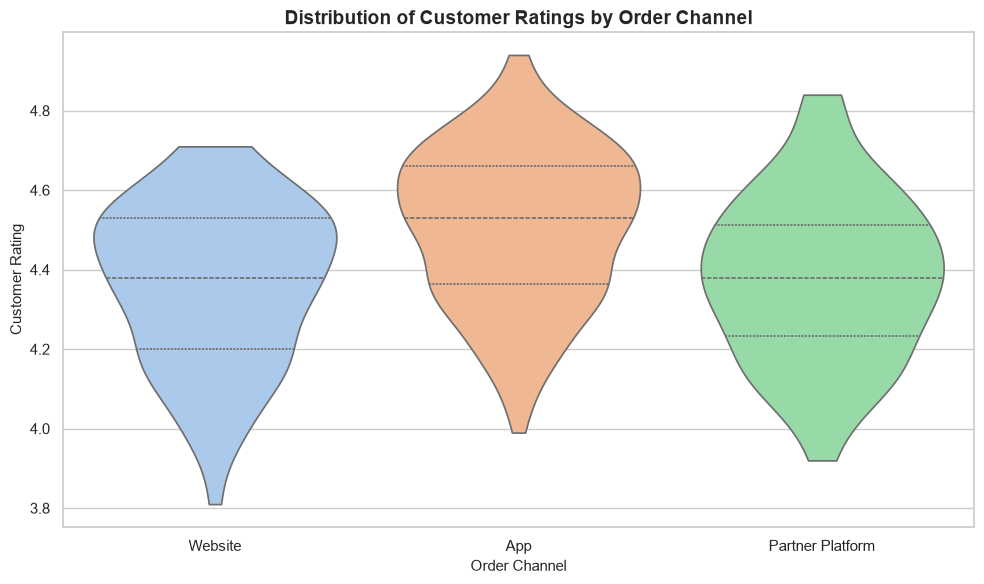

In [54]:
# Create a violin plot of customer ratings by order channel

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Order_Channel",
    y="Customer_Rating",
    hue="Order_Channel",
    palette="pastel",
    legend=False,
    inner="quartile",
    cut=0
)

plt.title(
    "Distribution of Customer Ratings by Order Channel",
    fontweight="bold"
)
plt.xlabel("Order Channel")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Orders placed through the App received the highest average customer rating of approximately **4.51**, with a median rating of **4.53**. Partner Platform and Website orders had slightly lower average ratings of approximately **4.38** and **4.37**, respectively. Although the rating distributions overlap, App orders generally show a higher level of customer satisfaction.

### 11.2 Frequency of Order Channels – Count Plot

A count plot is used to compare the number of order-batch records associated with each order channel in the dataset.

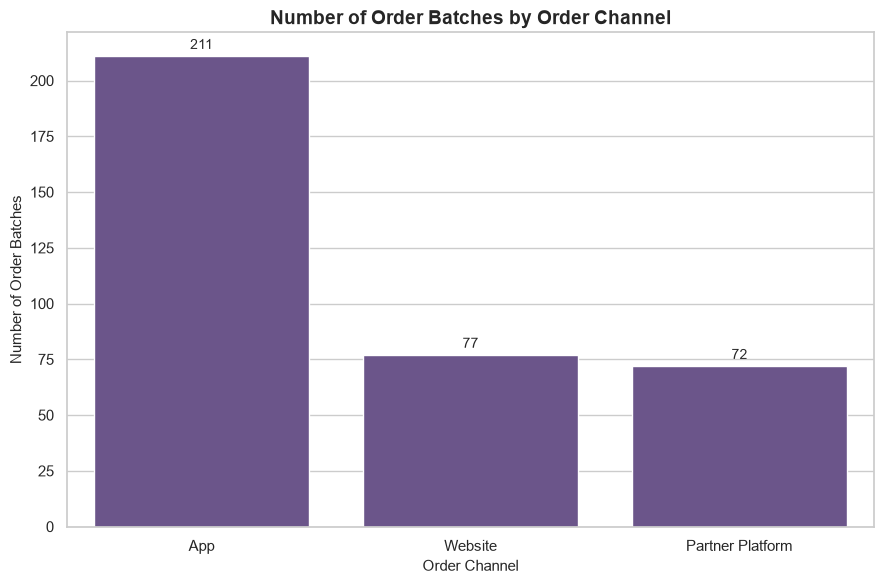

In [55]:
# Arrange the order channels by frequency

channel_order = df["Order_Channel"].value_counts().index

# Create the count plot

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="Order_Channel",
    order=channel_order,
    color="#6A4C93"
)

# Add count labels above the bars

ax.bar_label(
    ax.containers[0],
    padding=3,
    fontsize=10
)

plt.title("Number of Order Batches by Order Channel", fontweight="bold")
plt.xlabel("Order Channel")
plt.ylabel("Number of Order Batches")
plt.tight_layout()
plt.show()

#### 💡 Interpretation

The App channel appears in **211 of the 360 order-batch records**, accounting for approximately **58.6%** of the dataset. Website and Partner Platform appear in 77 and 72 records, respectively. This shows that the App was the dominant order channel represented in the business data.

## 12. Weather-Wise Business Performance

### 12.1 Preparing the Weather-Wise Summary

The dataset is grouped by weather condition to calculate total orders, total revenue, average delivery time, and average customer rating.

In [56]:
# Calculate performance measures for each weather condition

weather_performance = (
    df.groupby("Weather", as_index=False)
      .agg(
          Total_Orders=("Orders", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Average_Delivery_Time=("Avg_Delivery_Minutes", "mean"),
          Average_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Average_Rating", ascending=False)
)

weather_performance

,Weather,Total_Orders,Total_Revenue,Average_Delivery_Time,Average_Rating
0,Clear,21564,8994356.98,29.994521,4.530685
1,Cloudy,13628,5633965.72,31.719149,4.498830
2,Hot,6853,2672460.88,32.466667,4.472444
3,Rainy,11108,4512017.74,38.748000,4.232000


### 12.2 Average Customer Rating by Weather – Bar Chart

A bar chart is used to compare the average customer rating recorded under different weather conditions.

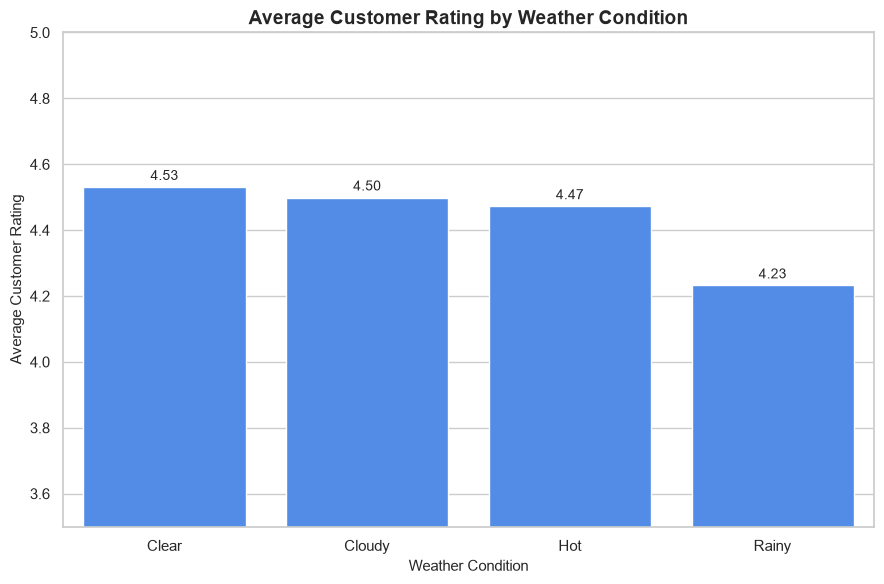

In [57]:
# Create a bar chart of average customer rating by weather

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=weather_performance,
    x="Weather",
    y="Average_Rating",
    order=weather_performance["Weather"],
    color="#3A86FF",
    errorbar=None
)

# Add average-rating labels above the bars

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3,
    fontsize=10
)

plt.title("Average Customer Rating by Weather Condition", fontweight="bold")
plt.xlabel("Weather Condition")
plt.ylabel("Average Customer Rating")
plt.ylim(3.5, 5.0)
plt.tight_layout()
plt.show()

#### 💡 Interpretation

Clear weather produced the highest average customer rating of approximately **4.53**, followed by Cloudy and Hot conditions. Rainy weather recorded the lowest average rating of approximately **4.23**. Combined with the longer delivery times observed during rainy conditions, this result suggests that weather-related delivery delays are associated with reduced customer satisfaction.

## 13. Correlation Analysis

### 13.1 Preparing the Correlation Matrix

A Pearson correlation matrix is calculated for the meaningful numerical business variables. Correlation values range from **−1 to +1**:

- A value close to **+1** indicates a strong positive relationship.
- A value close to **−1** indicates a strong negative relationship.
- A value close to **0** indicates little or no linear relationship.

In [58]:
# Select meaningful numerical variables for correlation analysis

numerical_columns = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]

# Calculate the Pearson correlation matrix

correlation_matrix = df[numerical_columns].corr()

correlation_matrix.round(2)

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
Orders,1.00,-0.01,0.76,0.18,0.40,0.12,-0.11,-0.00
Average_Order_Value,-0.01,1.00,0.58,0.08,0.30,-0.06,0.02,0.05
Revenue,0.76,0.58,1.00,0.20,0.52,0.05,-0.06,0.03
Marketing_Spend,0.18,0.08,0.20,1.00,0.75,-0.03,0.05,0.05
Discounts,0.40,0.30,0.52,0.75,1.00,-0.02,0.04,0.09
Avg_Delivery_Minutes,0.12,-0.06,0.05,-0.03,-0.02,1.00,-0.88,-0.76
Customer_Rating,-0.11,0.02,-0.06,0.05,0.04,-0.88,1.00,0.82
Repeat_Customer_Percent,-0.00,0.05,0.03,0.05,0.09,-0.76,0.82,1.00


### 13.2 Correlation Heatmap

A correlation heatmap is created to visually identify the strongest positive and negative relationships among the numerical business variables.

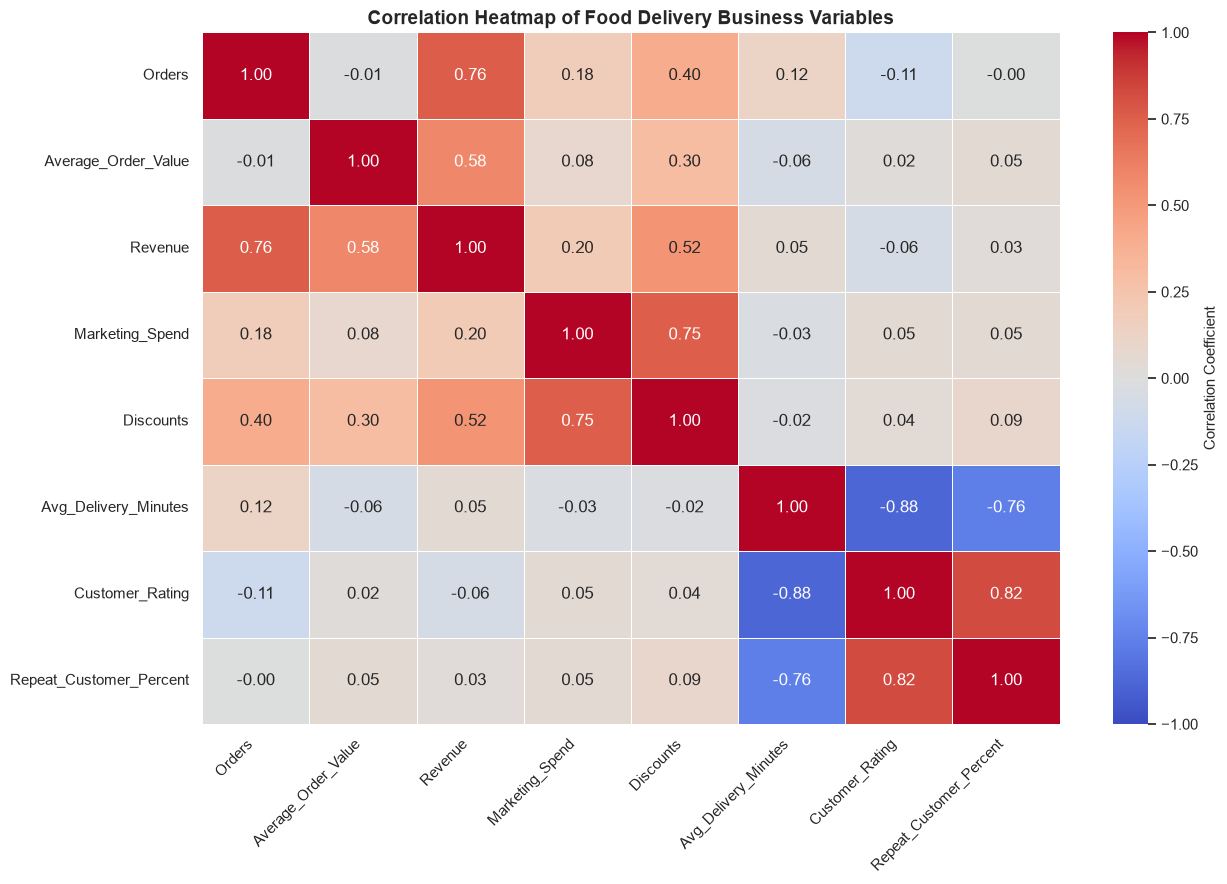

In [59]:
# Create the correlation heatmap

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title(
    "Correlation Heatmap of Food Delivery Business Variables",
    fontweight="bold"
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 💡 Interpretation

The correlation heatmap reveals several meaningful relationships:

- **Orders and Revenue (0.76):** Higher order volumes are strongly associated with higher revenue.
- **Average Order Value and Revenue (0.58):** Higher-value orders also contribute positively to revenue.
- **Delivery Time and Customer Rating (−0.88):** Longer delivery times are strongly associated with lower customer ratings.
- **Customer Rating and Repeat Customer Percentage (0.82):** Higher customer ratings are strongly associated with a greater percentage of repeat customers.
- **Delivery Time and Repeat Customer Percentage (−0.76):** Longer delivery times are associated with fewer repeat customers.
- **Marketing Spend and Revenue (0.20):** Marketing spend has only a weak positive relationship with revenue.
- **Marketing Spend and Discounts (0.75):** Higher marketing expenditure is strongly associated with larger discount amounts.

These correlations describe statistical associations and do not by themselves prove cause-and-effect relationships.

## 14. Key Findings

The most important findings obtained from the visualization portfolio are:

1. Monthly demand varied considerably throughout the year. **June recorded the highest number of orders with 5,816**, while February recorded the lowest with 2,853.

2. **December generated the highest total revenue of approximately ₹2.54 million**, followed by June with approximately ₹2.37 million.

3. **Bengaluru was the highest revenue-generating city** with approximately ₹3.85 million, closely followed by Delhi with approximately ₹3.81 million.

4. **Healthy cuisine received the highest number of orders with 10,024**, indicating the strongest overall cuisine demand in the dataset.

5. Marketing spend had only a **weak positive correlation of 0.20 with revenue**, showing that higher marketing expenditure was not consistently associated with proportionally higher revenue.

6. Delivery time had a **strong negative correlation of −0.88 with customer rating**, indicating that longer delivery times were associated with lower customer satisfaction.

7. Rainy weather produced the longest average delivery time of approximately **38.75 minutes** and the lowest average customer rating of approximately **4.23**.

8. The App was the dominant order channel, representing approximately **58.6% of order-batch records**, and it also achieved the highest average customer rating of approximately **4.51**.

9. Customer rating had a **strong positive correlation of 0.82 with repeat customer percentage**, suggesting that higher satisfaction is associated with stronger customer retention.

10. Order volume had a **strong positive correlation of 0.76 with revenue**, confirming that the number of orders is one of the most important revenue-related variables in the dataset.

## 15. Conclusion

The visualization portfolio provided a clear understanding of the patterns, distributions, category differences, and relationships within the Food Delivery Business Performance Dataset. Monthly analysis showed that orders and revenue varied throughout the year, with June and December emerging as strong-performing months. Bengaluru and Delhi generated the highest total revenue, while Healthy cuisine recorded the greatest overall order demand.

The relationship analysis showed that order volume and average order value were important revenue-related variables, whereas marketing spend had only a weak direct relationship with revenue. Delivery performance was strongly connected to customer experience, as longer delivery times were associated with lower customer ratings and fewer repeat customers. Rainy weather was linked with longer delivery times and lower satisfaction, while App-based orders achieved the highest average rating and represented the largest share of order-batch records.

Overall, the analysis highlights the importance of improving delivery efficiency, maintaining customer satisfaction, preparing for weather-related delays, and using data-driven strategies to strengthen revenue and customer retention.